In [ ]:
# IMPORTS
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from scipy import stats
import matplotlib.pyplot as plt

In [ ]:
# CONSTANTS
DIR = "data/"
DATASET = DIR + "analysisofcountriesFCC.csv"

SEED = 42
TRAIN_SIZE = 0.7
TEST_SIZE = 1 - TRAIN_SIZE
OBJECTIVE = "number of sessions"

# 1.1. Carga y preparación del dataset

In [124]:
# Carga del dataset
df = pd.read_csv(DATASET, sep=";", na_values=["#N/A"])
df.head()

,country,number of sessions,internet population (descendent order),ses/intpop,ses/(48%*tot_population),connectivity_index,ordered by number of citygroups (1==0),ISO3136,engprof
0,Afghanistan,10,30,16,6,6,2,AF,35.0
1,Albania,28,29,48,63,77,2,AL,35.0
2,Algeria,51,67,28,17,12,4,DZ,40.0
3,Argentina,86,98,47,60,72,5,AR,60.0
4,Armenia,31,20,64,64,51,2,AM,35.0


In [125]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 9 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   country                                 119 non-null    object 
 1   number of sessions                      119 non-null    int64  
 2   internet population (descendent order)  119 non-null    int64  
 3   ses/intpop                              119 non-null    int64  
 4   ses/(48%*tot_population)                119 non-null    int64  
 5   connectivity_index                      119 non-null    int64  
 6   ordered by number of citygroups (1==0)  119 non-null    int64  
 7   ISO3136                                 119 non-null    object 
 8   engprof                                 115 non-null    float64
dtypes: float64(1), int64(6), object(2)
memory usage: 8.5+ KB


None

Al observar el dataset, se observan las distintas variables:
- **country**: Variable categórica que contiene el nombre del país.
- **number of sessions**: Sesiones registradas en freeCodeCamp en el país.
- **internet population**: Población de dicho país con conexión a internet.
- **ses/intpop**: Relación entre internet population y number of sessions.
- **ses/(48%*tot_population)**: Relación entre internet population y number of sessions ajustada por un porcentaje.
- **connectivity_index**: Índice de conectividad del país.
- **ordered by number of citygroups (1==0)**: Indica la presencia de comunidades locales en el país.
- ISO3136: Variable categórica que contiene el código del país.
- **engprof**: Nivel del dominio del inglés en el país.

In [126]:
# Eliminación de nulos
display(df.isna().sum())
print("Número de filas antes de eliminar nulos:", len(df))
df = df.dropna()
print("Número de filas después de eliminar nulos:", len(df))

country                                   0
number of sessions                        0
internet population (descendent order)    0
ses/intpop                                0
ses/(48%*tot_population)                  0
connectivity_index                        0
ordered by number of citygroups (1==0)    0
ISO3136                                   0
engprof                                   4
dtype: int64

Número de filas antes de eliminar nulos: 119
Número de filas después de eliminar nulos: 115


Se observa que hay 4 registros con valores nulos en la variable **engprof**. Se van a eliminar dichos registros.

In [127]:
variables_numericas = df.select_dtypes(include="number")
rangos_intervalo = variables_numericas.agg(["min", "max"]).T
rangos_intervalo

,min,max
number of sessions,1.0,119.0
internet population (descendent order),2.0,119.0
ses/intpop,1.0,119.0
ses/(48%*tot_population),1.0,119.0
connectivity_index,1.0,119.0
ordered by number of citygroups (1==0),1.0,19.0
engprof,25.0,100.0


Al examinar los datos, se observa cómo no hay valores negativos en las variables numéricas, por lo que no se debe realizar tratamiento de valores negativos. 

Se va a observar si existen registros duplicados de la columna **country**.

In [128]:
df["country"][df["country"].duplicated(keep=False)].sort_values()

Series([], Name: country, dtype: object)

Como se observa, dicha variable no tiene ningún registro duplicado. En otras palabras, cada registro posee su propio valor. Por dicha razón, la variable no es útil para las predicciones al no haber posibles patrones entre distintos registros. Por esto se va a eliminar la columna del dataset. Se va a realizar lo mismo con la columna "**ISO3136**", dado que esta representa el código de cada país. En otras palabras, representa la misma información.

In [129]:
df = df.drop(columns=["country","ISO3136"])

Por último, también se va a eliminar **ses/intpop** y **ses/(48%*tot_population),** ya que sus valores dependen directamente de **number of sessions**, por lo que puede provocar data leakage.

In [130]:
df = df.drop(columns=["ses/intpop","ses/(48%*tot_population)"])

In [131]:
df.duplicated().sum()

np.int64(0)

También se observa que no existen valores duplicados, por lo que no es requerido su tratamiento.

Al final se han realizado los siguientes pasos sobre el dataset:
- Eliminación de nulos.
- Eliminación de las variables **country**, **ISO3136**, **ses/intpop** y **ses/(48%*tot_population)**.

El dataset acaba quedando de la siguiente manera:

In [132]:
df.head()

,number of sessions,internet population (descendent order),connectivity_index,ordered by number of citygroups (1==0),engprof
0,10,30,6,2,35.0
1,28,29,77,2,35.0
2,51,67,12,4,40.0
3,86,98,72,5,60.0
4,31,20,51,2,35.0


Por último, se van a realizar los pasos finales:
- Separar la variable objetivo del resto de variables.
- Dividir los datos en entrenamiento y validación.

En este caso no se va a estandarizar el dataset antes de entrenar el modelo, ya que Random Forest trabaja mediante árboles y reglas de decisión sobre los valores de las variables.

La variable objetivo que se ha seleccionado es **number of sessions**. Esta variable representa el número de sesiones de freeCodeCamp asociadas a cada país, por lo que constituye el resultado principal que se quiere predecir. Y, dado que **number of sessions** es una variable numérica, el problema puede plantearse como una tarea de regresión. El objetivo del modelo es estimar cuántas sesiones puede generar un país a partir de variables presentes en el dataset.

In [ ]:
X = df.drop(columns=[OBJECTIVE])
y = df[OBJECTIVE]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=SEED)

print(f"Tamaño de entrenamiento: {X_train.shape[0]} filas")
print(f"Tamaño de validación: {X_test.shape[0]} filas")
print(f"Variables explicativas: {list(X_train.columns)}")

Tamaño de entrenamiento: 80 filas
Tamaño de validación: 35 filas
Variables explicativas: ['internet population (descendent order)', 'connectivity_index', 'ordered by number of citygroups (1==0)', 'engprof']


# 1.2. Entrenamiento del modelo

En este notebook se va a entrenar un modelo de **Regresión Lineal**. 

Ya que este modelo predice un valor numérico a partir de una suma de efectos de las variables, se considera que es especialmente útil para el dataset en cuestión, ya que no solo permite obtener una predicción, sino que también permite interpretar de forma directa qué peso tiene cada atributo dentro de la predicción.

In [134]:
linear_regression_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])
linear_regression_model.fit(X_train, y_train)
y_pred_lr = linear_regression_model.predict(X_test)

# 1.3. Explicación del modelo

En esta sección se va a explicar el modelo de regresión lineal entrenado. Para ello se van a realizar dos tipos de explicaciones:

- **Explicación global**: Se observa el modelo completo, principalmente mediante el intercepto, los coeficientes, el error estándar, el valor absoluto de t y el p-value. Esto permite saber qué variables tienen más peso dentro del modelo.

- **Explicación individual**: Se observa una instancia concreta y se descompone su predicción como suma del intercepto y de las contribuciones de cada variable.

## 1.3.1. Evaluación del error del modelo

Antes de interpretar el modelo, se va a observar el error obtenido en el conjunto de validación. Dado que es un modelo de regresión lineal, este busca la mejor recta minimizando el error de predicción. Por esto, se van a calcular métricas de error y se van a representar los valores reales frente a los valores predichos.

In [135]:
linear_results = pd.DataFrame({
    "real_value": y_test,
    "predicted_value": y_pred_lr,
    "error": y_test - y_pred_lr,
    "absolute_error": (y_test - y_pred_lr).abs()
})
linear_results.head(10)

,real_value,predicted_value,error,absolute_error
85,109,105.770615,3.229385,3.229385
4,31,23.261804,7.738196,7.738196
42,14,8.174048,5.825952,5.825952
73,57,62.756320,-5.756320,5.756320
11,73,50.695847,22.304153,22.304153
47,90,82.976296,7.023704,7.023704
74,104,93.841064,10.158936,10.158936
70,41,13.395653,27.604347,27.604347
49,20,28.115075,-8.115075,8.115075
12,80,72.358497,7.641503,7.641503


In [ ]:
linear_metrics = pd.DataFrame({
    "metric": ["MAE", "RMSE", "R2"],
    "value": [
        mean_absolute_error(y_test, y_pred_lr),
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        r2_score(y_test, y_pred_lr)
    ]
})
linear_metrics

,metric,value
0,MAE,14.514259
1,RMSE,18.195458
2,R2,0.739444


Se observa que el modelo obtiene un **MAE de 14.51**, un **RMSE de 18.20** y un **R2 de 0.739**. En otras palabras, el modelo consigue explicar una parte relevante de la variabilidad de la variable objetivo, aunque todavía existen errores importantes en algunas instancias. Por esta razón, además de observar las métricas globales, también se va a observar gráficamente la relación entre los valores reales, los valores predichos y los residuos.

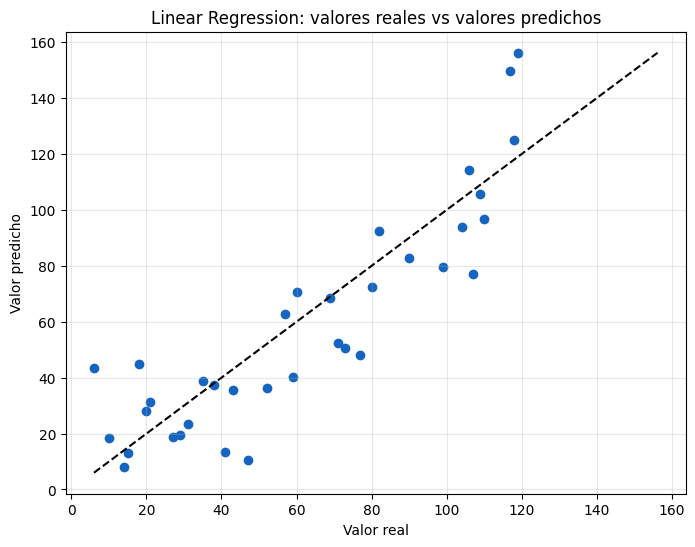

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lr, color="#1565C0")
min_value = min(y_test.min(), y_pred_lr.min())
max_value = max(y_test.max(), y_pred_lr.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--", color="black")
plt.xlabel("Valor real")
plt.ylabel("Valor predicho")
plt.title("Linear Regression: valores reales vs valores predichos")
plt.grid(alpha=0.3)
plt.show()

Se puede observar cómo la mayoría de puntos están relativamente cerca de la diagonal, por lo que el modelo tiene un rendimiento aceptable en bastantes instancias. De las **35 instancias** del conjunto de validación, **17** tienen un error absoluto menor o igual que **10 sesiones** y **26** tienen un error absoluto menor o igual que **20 sesiones**.

Aun así, la gráfica también muestra que hay varios puntos claramente alejados de la diagonal. Esto indica que el modelo no es estable para todas las instancias. Por ejemplo, se puede apreciar que tiene un valor real de **6 sesiones** y el modelo predice **43.63**. También se observa otra que tiene un valor real de **47 sesiones** y el modelo predice **10.50**. Por tanto, aunque el modelo recoge una tendencia general correcta, todavía comete errores grandes en casos concretos.

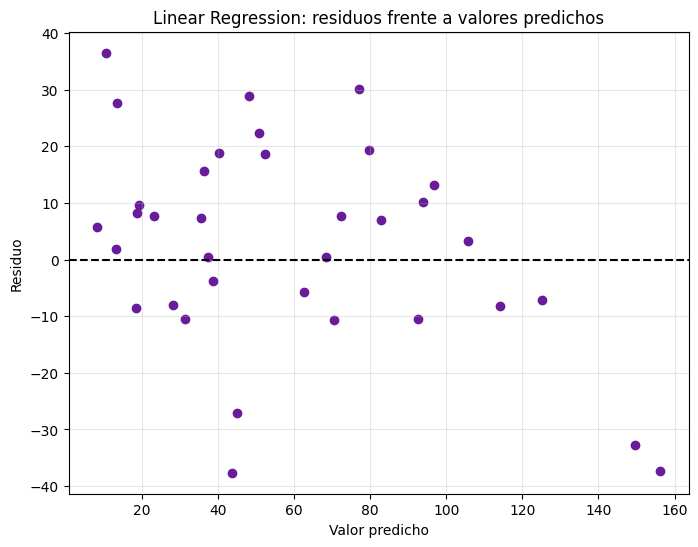

In [ ]:
residuals = y_test - y_pred_lr

plt.figure(figsize=(8, 6))
plt.scatter(y_pred_lr, residuals, color="#6A1B9A")
plt.axhline(0, linestyle="--", color="black")
plt.xlabel("Valor predicho")
plt.ylabel("Residuo")
plt.title("Linear Regression: residuos frente a valores predichos")
plt.grid(alpha=0.3)
plt.show()

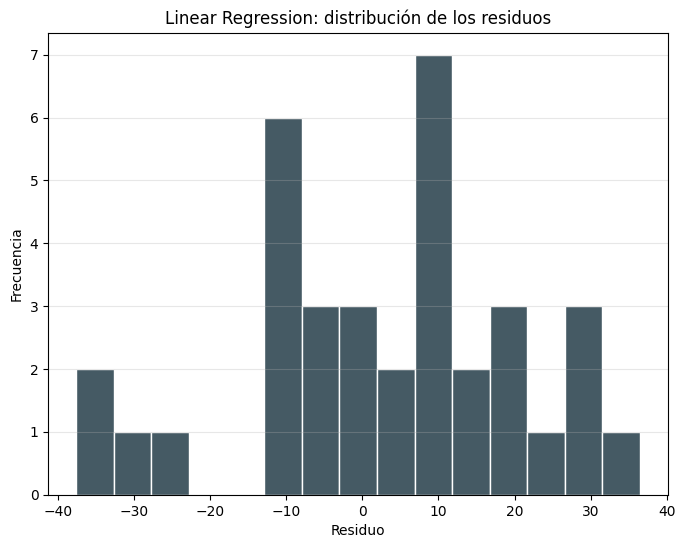

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=15, color="#455A64", edgecolor="white")
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.title("Linear Regression: distribución de los residuos")
plt.grid(axis="y", alpha=0.3)
plt.show()

En la gráfica de residuos se observa que la mayoría de errores se encuentran alrededor de valores moderados, pero no todos quedan cerca de 0. Concretamente, 26 de las 35 instancias tienen un error absoluto menor o igual que 20 sesiones, lo cual confirma que la mayor parte de predicciones no se aleja demasiado del valor real. También se observa que hay más casos donde el modelo se queda por debajo del valor real que casos donde predice por encima. En concreto, hay 22 infraestimaciones y 13 sobreestimaciones. También es importante recalcar que los errores extremos aparecen en ambos sentidos.

En el histograma se observa que los residuos se concentran principalmente en la zona central, pero aparecen colas hacia errores grandes positivos y negativos. Por dicha razón, se puede deducir que el modelo tiene un rendimiento global razonable, pero no controla bien algunas instancias alejadas del comportamiento medio.

## 1.3.2. Explicación global mediante coeficientes

A continuación, se va a interpretar el modelo de forma global. Ya que cada beta representa el peso de una variable, un coeficiente positivo indica que cuando aumenta dicha variable, también aumenta la predicción del modelo. En cambio, un coeficiente negativo indicaría que la variable reduce la predicción. Además de los coeficientes, se van a calcular **SE**, **|t|** y **p-value**.

In [ ]:
scaler = linear_regression_model.named_steps["scaler"]
trained_linear_model = linear_regression_model.named_steps["model"]

X_train_scaled = scaler.transform(X_train)
X_design = np.column_stack([np.ones(X_train_scaled.shape[0]), X_train_scaled])
train_residuals = y_train.values - linear_regression_model.predict(X_train)

degrees_freedom = X_design.shape[0] - X_design.shape[1]
residual_variance = np.sum(train_residuals ** 2) / degrees_freedom
covariance_matrix = residual_variance * np.linalg.inv(X_design.T @ X_design)
standard_errors = np.sqrt(np.diag(covariance_matrix))

betas = np.r_[trained_linear_model.intercept_, trained_linear_model.coef_]
t_values = betas / standard_errors
p_values = 2 * stats.t.sf(np.abs(t_values), df=degrees_freedom)

linear_statistics = pd.DataFrame({
    "feature": ["intercept"] + X_train.columns.tolist(),
    "beta": betas,
    "SE": standard_errors,
    "|t|": np.abs(t_values),
    "p_value": p_values
})
linear_statistics["absolute_beta"] = linear_statistics["beta"].abs()
linear_statistics.sort_values(by="absolute_beta", ascending=False)

,feature,beta,SE,|t|,p_value,absolute_beta
0,intercept,61.712500,1.727033,35.733254,7.582598e-49,61.712500
1,internet population (descendent order),16.831667,2.340727,7.190785,4.068877e-10,16.831667
3,ordered by number of citygroups (1==0),10.660986,2.424158,4.397810,3.556076e-05,10.660986
2,connectivity_index,7.162836,1.893371,3.783114,3.093729e-04,7.162836
4,engprof,5.788886,1.936165,2.989873,3.773150e-03,5.788886


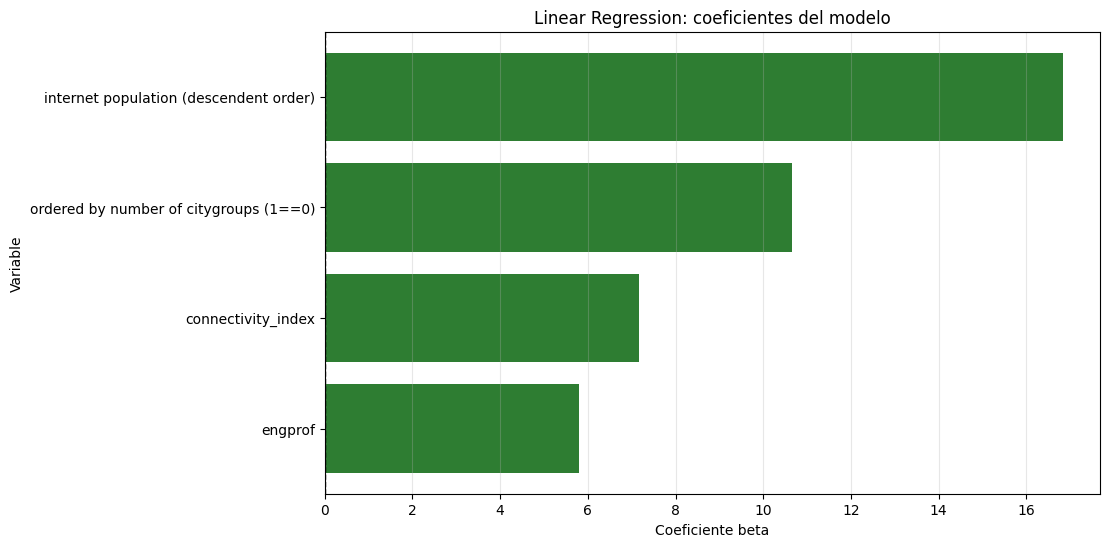

In [ ]:
linear_coefficients = linear_statistics[linear_statistics["feature"] != "intercept"].copy()
linear_coefficients = linear_coefficients.sort_values(by="beta", ascending=True)
colors = np.where(linear_coefficients["beta"] >= 0, "#2E7D32", "#C62828")

plt.figure(figsize=(10, 6))
plt.barh(linear_coefficients["feature"], linear_coefficients["beta"], color=colors)
plt.xlabel("Coeficiente beta")
plt.ylabel("Variable")
plt.title("Linear Regression: coeficientes del modelo")
plt.axvline(0, linestyle="--", color="black", linewidth=1)
plt.grid(axis="x", alpha=0.3)
plt.show()

En la gráfica de coeficientes se observa que todas las barras son positivas, lo que indica que el modelo relaciona correctamente todas las variables del dataset con la variable objetivo **number of sessions**. En concreto, se observa cómo **internet population (descending order)** posee la relación más fuerte con la variable objetivo, teniendo un beta aproximado de **16.83**. Por dicha razón, esta variable es la que más peso tiene en la predicción global del modelo. También se observa que esta variable tiene el mayor valor de **|t|**, aproximadamente **7.19**, y un **p-value** muy pequeño, por lo que es fácil definir dicha variable como la más importante en la lectura global del modelo.

Después aparecen ordenados por **número de citygroups (1==0)**, con beta aproximado de 10.66, y **connectivity_index**, con beta aproximado de **7.16**. Por último, **engprof** tiene la barra más pequeña, con beta aproximada de **5.79**. Por tanto, se define el orden de importancia de las variables para el modelo en el siguiente orden:

1. **internet population (descendent order)**.
2. **ordered by number of citygroups (1==0)**.
3. **connectivity_index**.
4. **engprof**.

## 1.3.3. Instancias con mayor error

Una vez interpretado el modelo de forma global, se va a investigar las instancias con mayor error absoluto, lo que va a permitir seleccionar un caso concreto para más adelante realizar una explicación individual.

In [ ]:
top_errors = linear_results.sort_values(by="absolute_error", ascending=False).head(10)
top_errors

,real_value,predicted_value,error,absolute_error
10,6,43.630701,-37.630701,37.630701
113,119,156.265408,-37.265408,37.265408
17,47,10.503148,36.496852,36.496852
112,117,149.663650,-32.663650,32.663650
104,107,76.982506,30.017494,30.017494
28,77,48.067589,28.932411,28.932411
70,41,13.395653,27.604347,27.604347
109,18,45.019225,-27.019225,27.019225
11,73,50.695847,22.304153,22.304153
117,99,79.680549,19.319451,19.319451


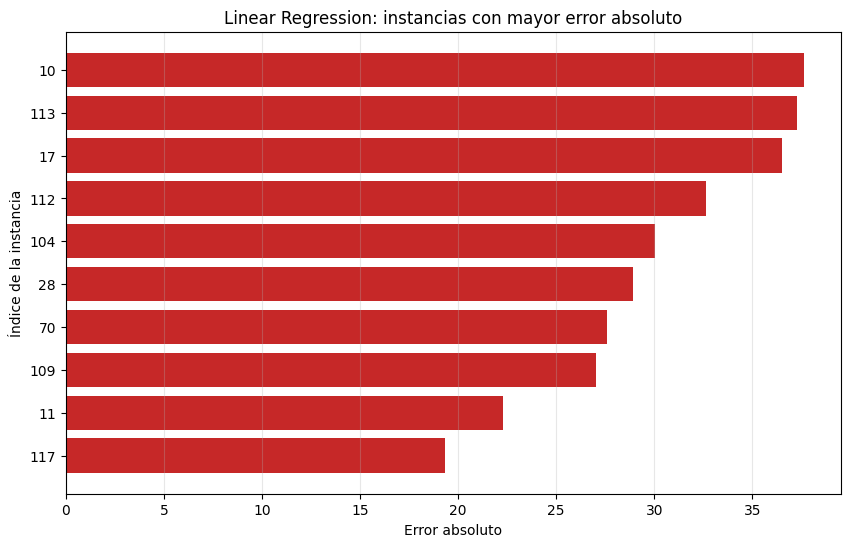

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(top_errors.index.astype(str), top_errors["absolute_error"], color="#C62828")
plt.ylabel("Índice de la instancia")
plt.xlabel("Error absoluto")
plt.title("Linear Regression: instancias con mayor error absoluto")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.show()

En la gráfica de errores absolutos se observa que las peores predicciones tienen errores bastante superiores al **MAE** global del modelo. Las instancias con mayor error son la 10 con **37.63**, la 113 con **37.27** y la 17 con **36.50**. Esto permite deducir que el modelo no falla de manera uniforme, sino que la mayoría de instancias tienen errores más moderados, pero unas pocas concentran errores muy altos. Por dicha razón, el rendimiento medio del modelo es aceptable, aunque estas instancias concretas reducen bastante la calidad global de la predicción.

## 1.3.4. Explicación individual de una instancia

Para explicar una predicción concreta en regresión lineal, se puede usar directamente la estructura del modelo. La predicción se obtiene sumando el intercepto y el efecto de cada variable. En otras palabras, cada contribución individual se calcula multiplicando el valor de la variable por su beta correspondiente. Dado que el modelo se ha entrenado con variables estandarizadas, en esta explicación se muestran tanto los valores originales como los valores estandarizados de la instancia.

In [ ]:
selected_index = linear_results.sort_values(by="absolute_error", ascending=False).index[0]
selected_instance = X_test.loc[[selected_index]]
selected_result = linear_results.loc[[selected_index]]

print(f"Instancia seleccionada: {selected_index}")
display(selected_instance)
display(selected_result)

Instancia seleccionada: 10


,internet population (descendent order),connectivity_index,ordered by number of citygroups (1==0),engprof
10,3,91,1,100.0


,real_value,predicted_value,error,absolute_error
10,6,43.630701,-37.630701,37.630701


In [ ]:
selected_instance_scaled = scaler.transform(selected_instance)
selected_instance_scaled = pd.DataFrame(selected_instance_scaled, columns=X_test.columns, index=selected_instance.index)

individual_explanation = pd.DataFrame({
    "feature": X_test.columns,
    "original_value": selected_instance.iloc[0].values,
    "scaled_value": selected_instance_scaled.iloc[0].values,
    "beta": trained_linear_model.coef_,
    "contribution": selected_instance_scaled.iloc[0].values * trained_linear_model.coef_
})
individual_explanation["absolute_contribution"] = individual_explanation["contribution"].abs()
individual_explanation = individual_explanation.sort_values(by="absolute_contribution", ascending=False)
individual_explanation

,feature,original_value,scaled_value,beta,contribution,absolute_contribution
0,internet population (descendent order),3.0,-1.835415,16.831667,-30.893098,30.893098
3,engprof,100.0,2.789677,5.788886,16.149124,16.149124
2,ordered by number of citygroups (1==0),1.0,-0.919162,10.660986,-9.799178,9.799178
1,connectivity_index,91.0,0.902066,7.162836,6.461353,6.461353


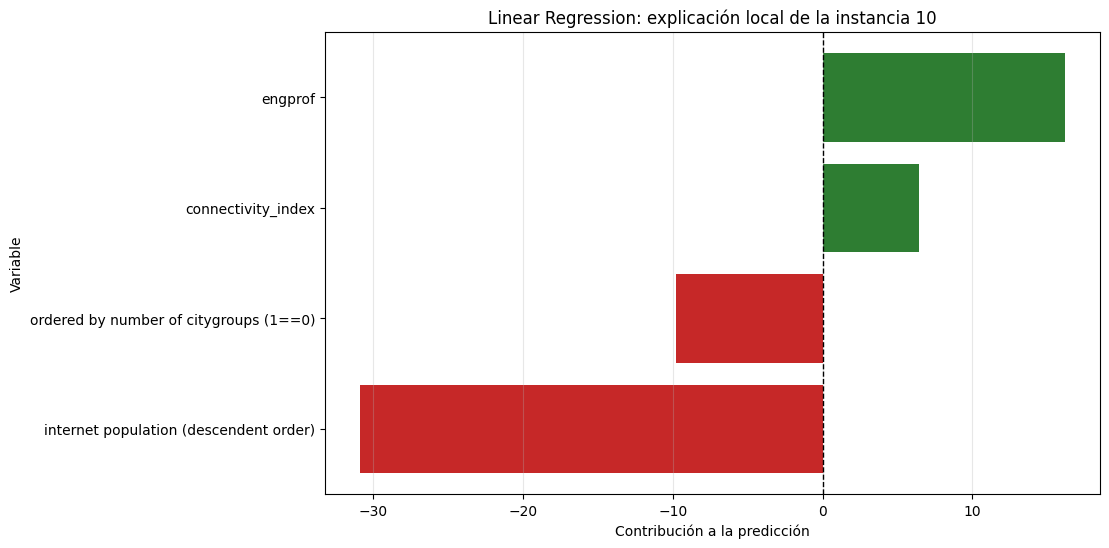

In [ ]:
local_sorted = individual_explanation.sort_values(by="contribution", ascending=True)
colors = np.where(local_sorted["contribution"] >= 0, "#2E7D32", "#C62828")

plt.figure(figsize=(10, 6))
plt.barh(local_sorted["feature"], local_sorted["contribution"], color=colors)
plt.xlabel("Contribución a la predicción")
plt.ylabel("Variable")
plt.title(f"Linear Regression: explicación local de la instancia {selected_index}")
plt.axvline(0, linestyle="--", color="black", linewidth=1)
plt.grid(axis="x", alpha=0.3)
plt.show()

In [ ]:
intercept = trained_linear_model.intercept_
sum_contributions = individual_explanation["contribution"].sum()
manual_prediction = intercept + sum_contributions
model_prediction = linear_regression_model.predict(selected_instance)[0]

print(f"Intercepto del modelo: {intercept:.2f}")
print(f"Suma de contribuciones: {sum_contributions:.2f}")
print(f"Predicción calculada manualmente: {manual_prediction:.2f}")
print(f"Predicción del pipeline: {model_prediction:.2f}")
print(f"Valor real: {selected_result['real_value'].iloc[0]:.2f}")
print(f"Error: {selected_result['error'].iloc[0]:.2f}")

Intercepto del modelo: 61.71
Suma de contribuciones: -18.08
Predicción calculada manualmente: 43.63
Predicción del pipeline: 43.63
Valor real: 6.00
Error: -37.63


Se observa que la instancia seleccionada es la **10**. Para dicha instancia, el valor real es 6 sesiones, mientras que el modelo predice aproximadamente 43.63 sesiones. Por tanto, el modelo está sobreestimando por mucho el valor real.

En la gráfica de contribuciones locales se observa que **internet population (descendent order)** es la variable que más reduce la predicción, con una contribución aproximada de **-30.89**. También reduce la predicción **ordered by number of citygroups (1==0)**, con una contribución aproximada de **-9.80**. Sin embargo, **engprof** aumenta la predicción en aproximadamente **16.15** y **connectivity_index** en aproximadamente **6.46**.

Aunque hay contribuciones negativas importantes, la suma final sigue dando una predicción demasiado alta para una instancia cuyo valor real es muy bajo. Por dicha razón, esta gráfica permite deducir que el error no se debe a una única variable, sino a que la combinación lineal de contribuciones no consigue ajustar bien este caso concreto.

# 1.4. Uso de IA generativa

El primer prompt utilizado fue para entender en mejor medida el ejercicio y los requisitos para cumplir. Se le envió a ChatGPT el enunciado entero del ejercicio.

```
PROJECT TASK 
The goal of practical project is to explain, using all suitable techniques explained in class, the ML models assigned. At least each team must explain 2 ML models (a.k.a. compulsory models). Additionally, the team can build and explain a third model (a.k.a. extra model). 

The Practical Project will consist of: 
• Python 2 or 3 notebooks: ipynb file for each model. 
• Dataset: csv file or online load hardcoded. 

Each notebook must include: 
• Markdown use: o Sections and subsections numbered (using #, ##, etc.) o Concise and clear descriptions of the decisions made o Concise and clear conclusions of the explanations obtained. 
• The code must be clear and must include comments. 
• The notebook must include 3 sections (you can add subsections): 
1. Dataset load and preparation 
2. ML model training 
3. ML explanation 
4. Generative AI section (see genAI disclaimant) 

The ML explanation, section 3, is the most important part of the project. Here you should cover: 
• Use any explanation method useful that you’ve seen on class. 
• Provide individual explanations of instance. Not just plots, but the conclusions you can make. 
• Provide global explanations of the ML model. Not just plots, but the conclusions you can make. 

IMPORTANT You must perform data preparation pipeline and model training properly. However, do not focus on doing a great data preparation pipeline. Do not focus on training the best ML model ever! This subject is about explaining a model, not building it. You will not get a better mark if you make a great work on sections 1,2. 

Que me pide exactamente el ejercicio?
```

El siguiente prompt fue para determinar, de las dos opciones a elegir, cuál es la más sencilla de implementar.

```
Versión 1: 
- Datasets: https://data.nysed.gov/downloads.php (debo elegir un dataset pequeño) 
- Debe ser una tarea de clasificación 
- Modelos a utilizar: LogisticReg, Random Forest, Basic Neuronal Network (solo debo elegir dos) 

Versión 2: 
- Dataset: https://github.com/freeCodeCamp/open-data/tree/master/google-analytics/countries-fCC/data 
- Debe ser una tarea de regresión 
- Modelos a utilizar: Linear Reg, Random Forest Reg, SVN regression (solo debo elegir dos) 

Cual de las dos versiones consideras que es más sencilla de utilizar?
```

Fue así como me recomendó utilizar la versión 2 con Linear Reg y Random Forest.

También quise un análisis más detallado del contexto del dataset elegido, así que directamente se lo pregunté.

```
Explícame en qué consiste el dataset
```

Tras realizar la preparación inicial del dataset, pregunté si sería recomendable que aplicara algo más.

```
Al dataset le aplico esto: 
- cargo el dataset 
- elimino los nulos 
- Miro si hay valores negativos, los cuales no hay 

Hago algo más?
```

A la hora de probar si había registros duplicados en la columna **columns**, intenté hacer el código por mi cuenta, pero no me funcionó, así que decidí consultar a ChatGPT.

```
Quiero ver los datos de Country que tengan más de 1 registro df[df["country"].value_counts() > 1].sort_values("country")
```

No me entendió de primeras, así que tuve que preguntarle de vuelta con otras palabras.

```
Lo que quiero es esto: 
Quedarme solo con la columna country y ver de entre dicha columna los valores duplicados que hay
```

Finalmente, hice este último prompt:

```
Para cada modelo, dame cuáles son las mejores métricas para evaluar a dicho modelo. 
Dame también algunos snippets de código.
```

Para que supiera mejor cómo se cursa la asignatura, le di contexto dándole información presente en las diapositivas de la asignatura. Y con las métricas que me recomendó, hice un cribado para elegir las que yo mejor consideraba. También usé dichos snippets de código, modificándolos para adecuarse en mejor medida a la práctica.